# Effective rank: diffusion samples vs real states vs N(0,I)

Effective rank $d_{\mathrm{eff}} = (\sum_i \lambda_i)^2 / \sum_i \lambda_i^2$ over covariance
eigenvalues of test-set hidden states (real), diffusion samples from the ten trained
networks (5 layers x widths {1024, 8196}), and an independent standard-normal baseline.

- Left: full 4096-d ambient space (log scale — random sits near 2250, real at 12-38)
- Right: PCA-32 subspace fitted on training data (random ~31.8 = isotropic in the chart)

Sources: `outputs/layer_XX/metrics/eval.json` (8196 run) and
`runs/mlp1024/outputs/layer_XX/metrics/eval.json` (1024 run), computed at each
network's best checkpoint. Colors as before: red = 1024-wide, blue = 8196-wide,
darker = deeper layer; real = black, random = dashed gray.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
LAYERS = [1, 8, 16, 24, 32]
SOURCES = {
    "1024": ROOT / "runs/mlp1024/outputs",
    "8196": ROOT / "outputs",
}

rows = {}
for width, out in SOURCES.items():
    for layer in LAYERS:
        ev = json.loads((out / f"layer_{layer:02d}" / "metrics" / "eval.json").read_text())
        rows[(width, layer)] = {
            "step": ev["step"],
            "d_eff_real": ev["d_eff_real"],
            "d_eff_diff": ev["d_eff_diffusion"],
            "d_eff_random": ev["d_eff_random"],
            "pca_d_eff_real": ev["pca_d_eff_real"],
            "pca_d_eff_diff": ev["pca_d_eff_diffusion"],
            "pca_d_eff_random": ev["pca_d_eff_random"],
        }

print(f"{'width':>6} {'layer':>5} {'best@':>6} | {'real':>7} {'diff':>7} {'random':>8} | "
      f"{'pca real':>8} {'pca diff':>8} {'pca rand':>8}")
for (w, l), r in sorted(rows.items()):
    print(f"{w:>6} {l:>5} {r['step']:>6} | {r['d_eff_real']:>7.2f} {r['d_eff_diff']:>7.2f} "
          f"{r['d_eff_random']:>8.1f} | {r['pca_d_eff_real']:>8.2f} {r['pca_d_eff_diff']:>8.2f} "
          f"{r['pca_d_eff_random']:>8.2f}")

 width layer  best@ |    real    diff   random | pca real pca diff pca rand
  1024     1  17000 |   38.26    5.35   2250.9 |     3.19     1.68    31.79
  1024     8   4000 |   14.31    1.39   2250.9 |     3.24     1.18    31.79
  1024    16  17000 |   12.01   10.39   2250.9 |     3.55     5.27    31.81
  1024    24  10500 |   22.30   12.01   2250.9 |     6.87     4.32    31.79
  1024    32  17000 |   11.53    4.22   2250.9 |     5.11     2.97    31.77
  8196     1  37000 |   38.26    5.24   2250.9 |     3.20     2.22    31.78
  8196     8  40500 |   14.31   14.45   2250.9 |     3.23     4.27    31.81
  8196    16  40500 |   12.01   31.48   2250.9 |     3.54     7.96    31.81
  8196    24  40500 |   22.30   19.27   2250.9 |     6.88     9.73    31.80
  8196    32  40500 |   11.53   14.83   2250.9 |     5.10     5.95    31.79


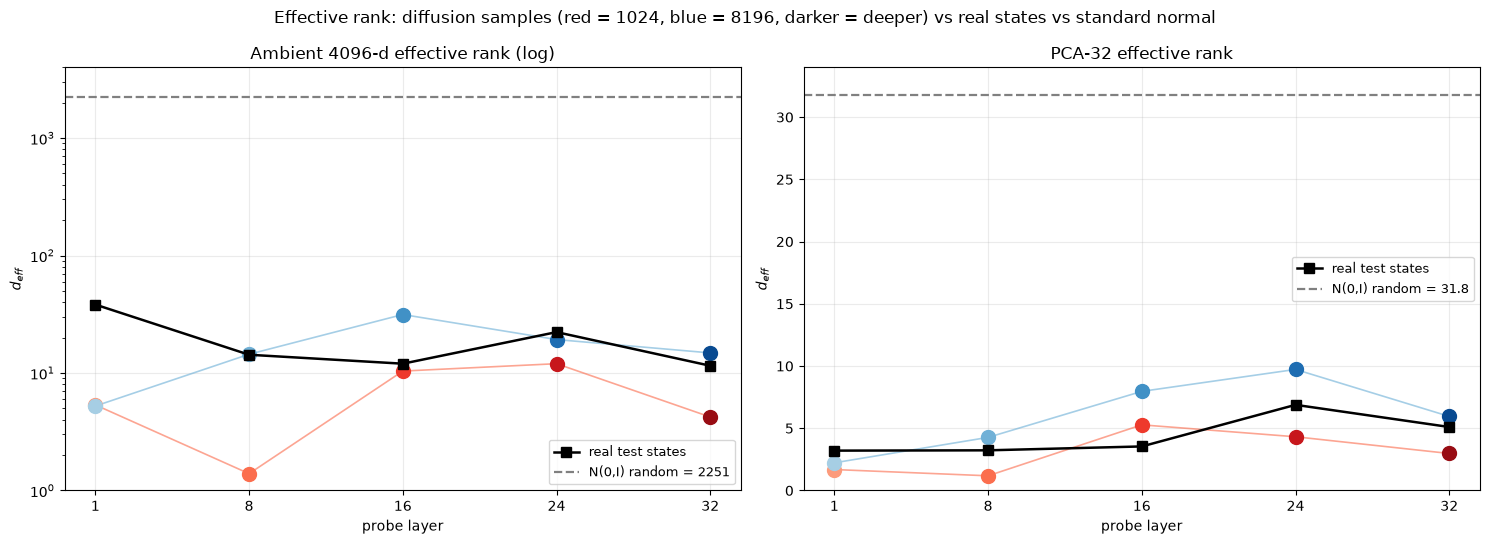

In [2]:
fig, (ax_a, ax_p) = plt.subplots(1, 2, figsize=(15, 5.5))
shades = np.linspace(0.35, 0.9, len(LAYERS))
cmap = {"1024": plt.cm.Reds, "8196": plt.cm.Blues}
x = np.arange(len(LAYERS))

for width in ("1024", "8196"):
    for ax, key in ((ax_a, "d_eff_diff"), (ax_p, "pca_d_eff_diff")):
        ys = [rows[(width, l)][key] for l in LAYERS]
        ax.plot(x, ys, "-", color=cmap[width](0.5), lw=1.2, alpha=0.6, zorder=2)
for i, (shade, layer) in enumerate(zip(shades, LAYERS)):
    for width in ("1024", "8196"):
        for ax, key in ((ax_a, "d_eff_diff"), (ax_p, "pca_d_eff_diff")):
            ax.plot(x[i], rows[(width, layer)][key], "o", color=cmap[width](shade),
                    ms=10, zorder=3)

real = [rows[("8196", l)]["d_eff_real"] for l in LAYERS]
pca_real = [rows[("8196", l)]["pca_d_eff_real"] for l in LAYERS]
ax_a.plot(x, real, "s-", color="black", lw=1.8, ms=7, label="real test states", zorder=4)
ax_p.plot(x, pca_real, "s-", color="black", lw=1.8, ms=7, label="real test states", zorder=4)

rand = rows[("8196", 1)]["d_eff_random"]
pca_rand = rows[("8196", 1)]["pca_d_eff_random"]
ax_a.axhline(rand, color="gray", ls="--", lw=1.6, label=f"N(0,I) random = {rand:.0f}")
ax_p.axhline(pca_rand, color="gray", ls="--", lw=1.6, label=f"N(0,I) random = {pca_rand:.1f}")

for ax, title in ((ax_a, "Ambient 4096-d effective rank (log)"),
                  (ax_p, "PCA-32 effective rank")):
    ax.set_xticks(x, [str(l) for l in LAYERS])
    ax.set_xlabel("probe layer")
    ax.set_ylabel("$d_{eff}$")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

ax_a.set_yscale("log")
ax_a.set_ylim(1, 4000)
ax_p.set_ylim(0, 34)

fig.suptitle("Effective rank: diffusion samples (red = 1024, blue = 8196, darker = deeper) "
             "vs real states vs standard normal")
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "effective_rank.png", dpi=160)
plt.show()

Reference lines: ambient dimension 4096 and PCA rank 32 are the hard ceilings.
Real effective rank is non-monotone with depth (highest at layer 1, ~38; dips at
16 and 32), while the random baseline is near-isotropic (~2250 of 4096 ambient,
~31.8 of 32 in the PCA chart). Diffusion samples sit far below random in the
ambient space — they concentrate on a learned low-dimensional manifold.